# Credit Card Fraud Detection Using Autoencoder


## Deep learning

## Declare required dependencies

In [1]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

## Data ingestion

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/IT_customer_churn.csv.xls')

## Data exploration

In [4]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Partner — Наличие партнера<br>
Dependents — Наличие иждивенцев<br>
tenure — Стаж обслуживания в месяцах<br>
PhoneService — Наличие услуги телефонии<br>
MultipleLines — Наличие нескольких телефонных линий<br>
InternetService — Тип интернет-услуг (DSL, оптоволокно, нет)<br>
OnlineSecurity — Наличие услуги онлайн-безопасности<br>
OnlineBackup — Наличие услуги онлайн-резервного копирования<br>
DeviceProtection — Наличие услуги защиты устройств<br>
TechSupport — Наличие услуги технической поддержки<br>
StreamingTV — Наличие услуги стриминга ТВ<br>
StreamingMovies — Наличие услуги стриминга фильмов<br>
Contract — Тип контракта (помесячный, на 1 год, на 2 года)<br>
PaperlessBilling — Использование безбумажного биллинга<br>
PaymentMethod — Способ оплаты (электронный чек, чек по почте, банковский перевод, кредитная карта)<br>
MonthlyCharges — Ежемесячная плата в долларах<br>
TotalCharges — Общая сумма всех платежей в долларах<br>
Churn — Отток клиента (Yes — ушел, No — остался)<br>

In [64]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Применяем LabelEncoder ко всем текстовым столбцам
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


Столбцы преобразованы

In [6]:
print(df_encoded.shape)
print(df_encoded.describe())

(7043, 20)
            gender  SeniorCitizen      Partner   Dependents       tenure  \
count  7043.000000    7043.000000  7043.000000  7043.000000  7043.000000   
mean      0.504756       0.162147     0.483033     0.299588    32.371149   
std       0.500013       0.368612     0.499748     0.458110    24.559481   
min       0.000000       0.000000     0.000000     0.000000     0.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       1.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  MultipleLines  InternetService  OnlineSecurity  \
count   7043.000000    7043.000000      7043.000000     7043.000000   
mean       0.903166       0.940508         0.872923        0.790004   
std        0.295752       0.948554         0.737796        0.859848   
min        0.000000 

In [7]:
df.isnull().values.any()

np.False_

Пропусков нет

## Class distribution

In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


/tmp/ipykernel_17162/4221569539.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Churn'], sort = True)


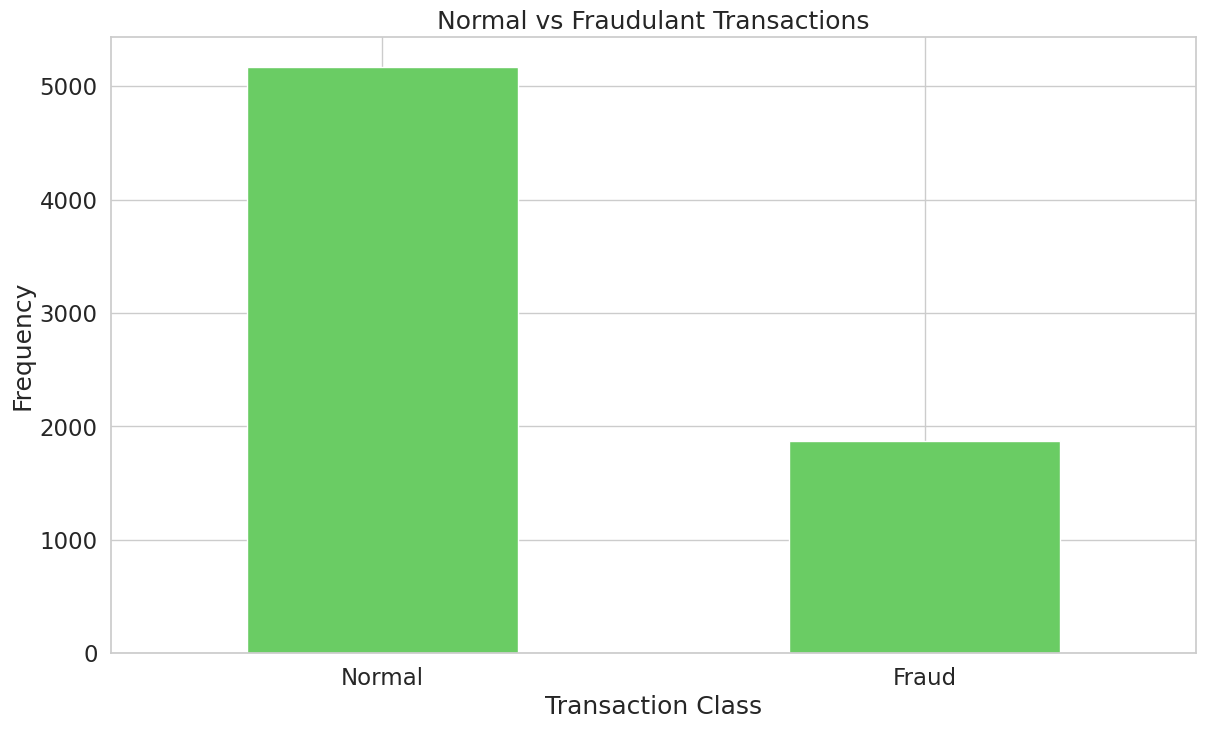

In [9]:
count_classes = pd.value_counts(df['Churn'], sort = True)
count_classes.plot(kind = 'bar', rot=0, color="g")
plt.title("Normal vs Fraudulant Transactions")
plt.xticks(range(2), LABELS)
plt.xlabel("Transaction Class")
plt.ylabel("Frequency");

Видно что набор данных несбалансирован

In [10]:
fraudsDF = df_encoded[df_encoded['Churn'] == 1]
normalDF = df_encoded[df_encoded['Churn'] == 0]

In [11]:
fraudsDF.shape

(1869, 20)

In [12]:
normalDF.shape

(5174, 20)

In [13]:
fraudsDF.tenure.describe()

,tenure
count,1869.000000
mean,17.979133
std,19.531123
min,1.000000
25%,2.000000
50%,10.000000
75%,29.000000
max,72.000000


In [14]:
normalDF.tenure.describe()

,tenure
count,5174.000000
mean,37.569965
std,24.113777
min,0.000000
25%,15.000000
50%,38.000000
75%,61.000000
max,72.000000


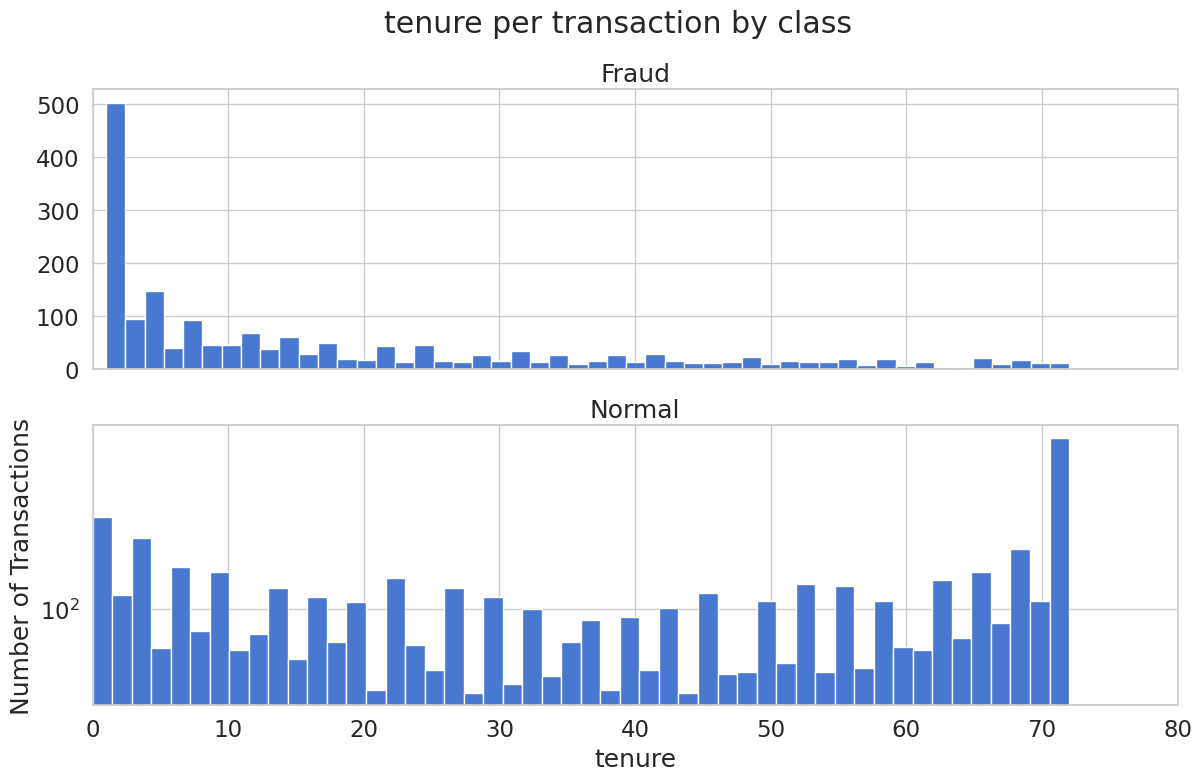

In [15]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('tenure per transaction by class')

bins = 50

ax1.hist(fraudsDF.tenure, bins = bins)
ax1.set_title('Fraud')

ax2.hist(normalDF.tenure, bins = bins)
ax2.set_title('Normal')

plt.xlabel('tenure')
plt.ylabel('Number of Transactions')
plt.xlim((0, 80))
plt.yscale('log')
plt.show();

Люди чаще всего уходят в первые 10 месяцев. Чем дольше клиент остается, тем меньше вероятность его ухода.

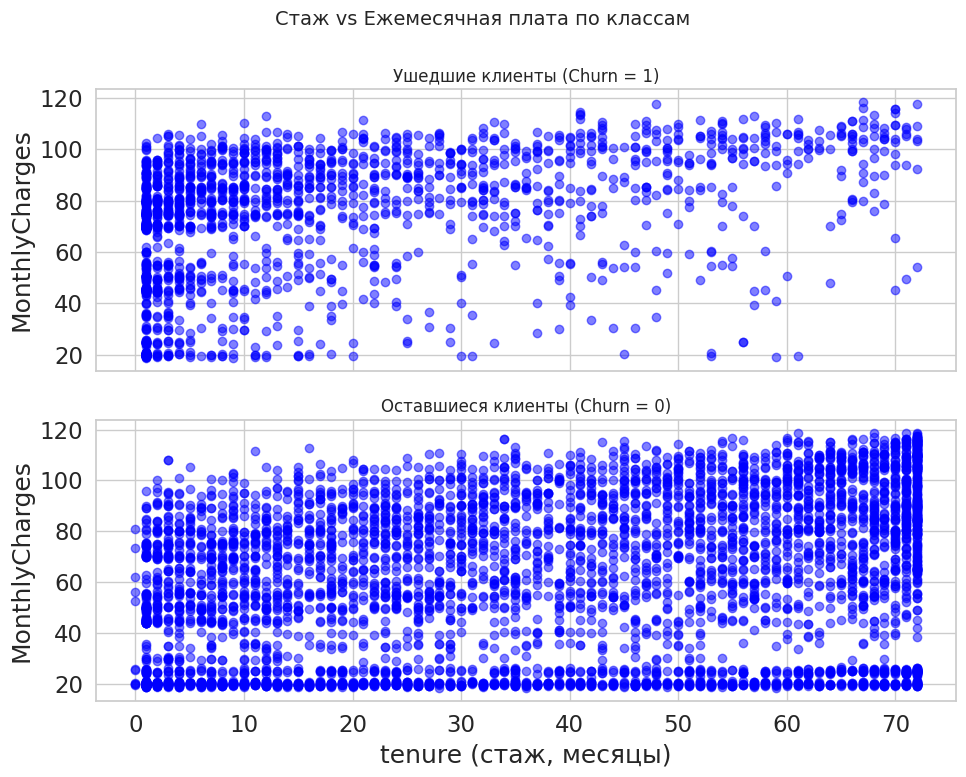

In [16]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
f.suptitle('Стаж vs Ежемесячная плата по классам', fontsize=14)

# Ушедшие клиенты (Churn = 1)
ax1.scatter(fraudsDF['tenure'], fraudsDF['MonthlyCharges'], alpha=0.5, color='blue')
ax1.set_title('Ушедшие клиенты (Churn = 1)', fontsize=12)
ax1.set_ylabel('MonthlyCharges')

# Оставшиеся клиенты (Churn = 0)
ax2.scatter(normalDF['tenure'], normalDF['MonthlyCharges'], alpha=0.5, color='blue')
ax2.set_title('Оставшиеся клиенты (Churn = 0)', fontsize=12)
ax2.set_xlabel('tenure (стаж, месяцы)')
ax2.set_ylabel('MonthlyCharges')

plt.tight_layout()
plt.show()

График показывает, что самая проблемная зона — это новые клиенты с дорогими тарифами. Именно они уходят чаще всего. Клиенты с большим стажем, независимо от тарифа, чаще всего остаются.

## Preprocessing

In [17]:
transactionData = df.drop(['MonthlyCharges'], axis=1)

In [18]:
transactionData['tenure'] = StandardScaler().fit_transform(transactionData['tenure'].values.reshape(-1, 1))

### Разделите набор данных на наборы обучающих и тестовых данных.

In [19]:
# Задаем random seed для воспроизводимости
RANDOM_SEED = 42

# Разделяем данные на обучающую и тестовую выборки (80% / 20%)
X_train, X_test = train_test_split(df_encoded, test_size=0.2, random_state=RANDOM_SEED)

# В обучающем наборе оставляем ТОЛЬКО ОСТАВШИХСЯ клиентов (Churn = 0)
X_train = X_train[X_train['Churn'] == 0]

# Удаляем целевую переменную из обучающего набора
X_train = X_train.drop(['Churn'], axis=1)

# Сохраняем целевую переменную из тестового набора
y_test = X_test['Churn']

# Удаляем целевую переменную из тестового набора
X_test = X_test.drop(['Churn'], axis=1)

X_train = X_train.values
X_test = X_test.values
y_test = y_test.values

print(f"Размер тестовой выборки: {y_test.size}")

Размер тестовой выборки: 1409


In [20]:
# Нормализуем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # ← используйте это для обучения
X_test_scaled = scaler.transform(X_test)

# Проверяем результат
print(f"X_train_scaled mean: {X_train_scaled.mean():.6f}")  # должно быть ~0
print(f"X_train_scaled std: {X_train_scaled.std():.6f}")   # должно быть ~1
print(f"X_train_scaled min: {X_train_scaled.min():.2f}")
print(f"X_train_scaled max: {X_train_scaled.max():.2f}")

# Преобразуем в тензоры
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)

X_train_scaled mean: 0.000000
X_train_scaled std: 1.000000
X_train_scaled min: -3.01
X_train_scaled max: 2.61


In [21]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(19, 14),
            nn.Tanh(),
            nn.Linear(14, 7),
            nn.LeakyReLU(),
            )

        self.decoder = nn.Sequential(
           nn.Linear(7, 7),
           nn.Tanh(),
           nn.Linear(7, 19),
           nn.LeakyReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [22]:
model = Autoencoder()

In [23]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

In [24]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)

In [25]:
train_dataset = data_utils.TensorDataset(X_train_tensor, X_train_tensor)
train_loader = data_utils.DataLoader(train_dataset, batch_size=32, shuffle=True)

In [26]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
model.parameters(), lr=learning_rate, weight_decay=10e-05)

In [27]:
history = {}
history['train_loss'] = []
history['test_loss'] = []

In [28]:
for epoch in range(num_epochs):
    h = np.array([])
    for data, target in train_loader:
        #print(type(data))
        #data = Variable(data).cpu()
        #print(type(data))
        # ===================forward=====================
        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # ===================log========================
    mean_loss = np.mean(h)
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch + 1, num_epochs, mean_loss))
    history['train_loss'].append(mean_loss)


torch.save(model.state_dict(), './IT_customer_model.pth')

epoch [1/100], loss:0.9893
epoch [2/100], loss:0.8842
epoch [3/100], loss:0.8165
epoch [4/100], loss:0.7802
epoch [5/100], loss:0.7562
epoch [6/100], loss:0.7401
epoch [7/100], loss:0.7296
epoch [8/100], loss:0.7205
epoch [9/100], loss:0.7143
epoch [10/100], loss:0.7062
epoch [11/100], loss:0.6994
epoch [12/100], loss:0.6927
epoch [13/100], loss:0.6873
epoch [14/100], loss:0.6834
epoch [15/100], loss:0.6789
epoch [16/100], loss:0.6749
epoch [17/100], loss:0.6703
epoch [18/100], loss:0.6655
epoch [19/100], loss:0.6611
epoch [20/100], loss:0.6568
epoch [21/100], loss:0.6530
epoch [22/100], loss:0.6494
epoch [23/100], loss:0.6468
epoch [24/100], loss:0.6433
epoch [25/100], loss:0.6405
epoch [26/100], loss:0.6383
epoch [27/100], loss:0.6357
epoch [28/100], loss:0.6336
epoch [29/100], loss:0.6321
epoch [30/100], loss:0.6300
epoch [31/100], loss:0.6294
epoch [32/100], loss:0.6277
epoch [33/100], loss:0.6268
epoch [34/100], loss:0.6252
epoch [35/100], loss:0.6239
epoch [36/100], loss:0.6229
e

In [29]:
print(f"Длина train_loss: {len(history['train_loss'])}")
print(f"train_loss: {history['train_loss']}")

Длина train_loss: 100
train_loss: [np.float64(0.9892802133009984), np.float64(0.884167679456564), np.float64(0.8165454892011789), np.float64(0.7802383395341727), np.float64(0.7562055032986861), np.float64(0.740149462223053), np.float64(0.7295814720483926), np.float64(0.7205163079958695), np.float64(0.7142548538171328), np.float64(0.7062105486026177), np.float64(0.6993920592161326), np.float64(0.6927291929721833), np.float64(0.6872626841068268), np.float64(0.6833936232786912), np.float64(0.6788801326201512), np.float64(0.6748862257370583), np.float64(0.6702594436131991), np.float64(0.6655313102098611), np.float64(0.6610645170395191), np.float64(0.6567663926344651), np.float64(0.6529629881565387), np.float64(0.6493990389200357), np.float64(0.646783809019969), np.float64(0.6432981381049523), np.float64(0.640533932355734), np.float64(0.6382675345127399), np.float64(0.6357478416883029), np.float64(0.6336108842721352), np.float64(0.6321204900741577), np.float64(0.6299934772344736), np.float6

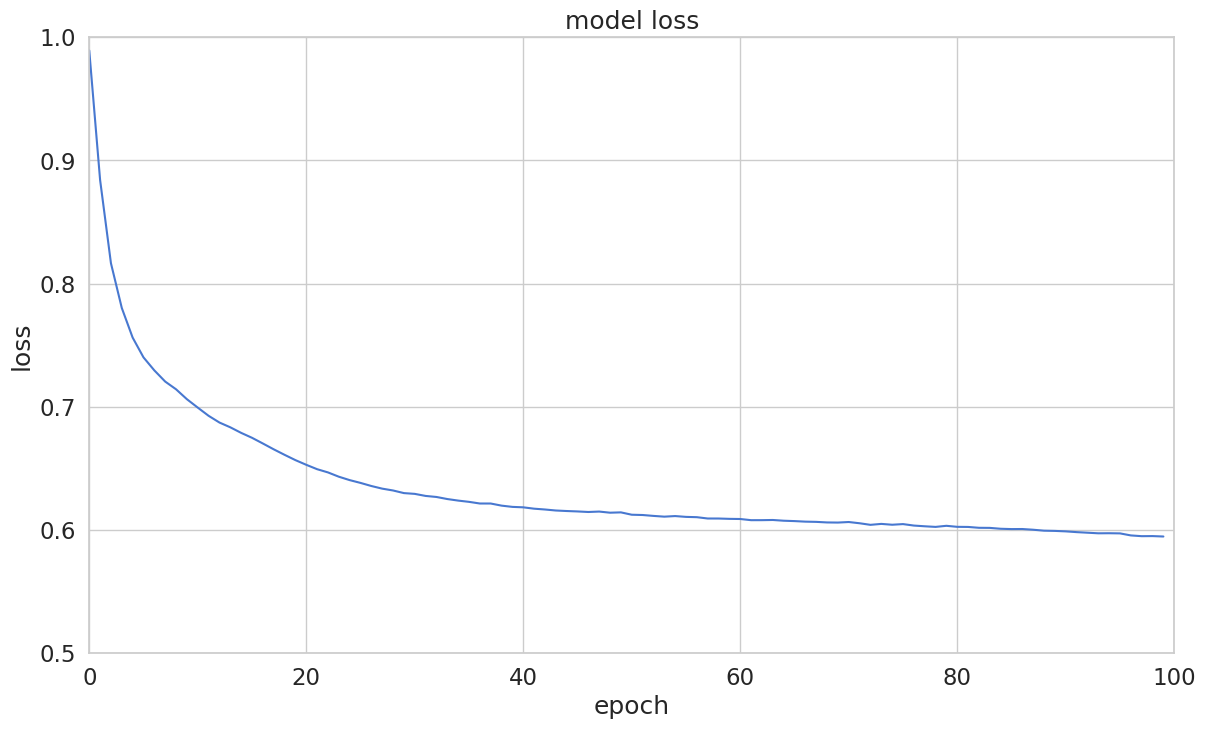

In [30]:
#history['train_loss']
#plt.plot(range(num_epochs),history['train_loss'],'ro',linewidth=2.0)
plt.plot(history['train_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.axis([0, 100, 0.5, 1])
#plt.legend(['train', 'test'], loc='upper right');
plt.show()

Динамика снижения ошибки (loss) автоэнкодера в процессе обучения хорошая (снижается плавно).

In [31]:
# Создаем тензор
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Создаем Dataset и DataLoader
test_dataset = data_utils.TensorDataset(X_test_tensor)
test_loader = data_utils.DataLoader(test_dataset, batch_size=1, shuffle=False)

In [32]:
pred_losses = {'pred_loss' : []}
model.eval()
with torch.no_grad():
   # test_loss = 0
    for data in test_loader:
        inputs = data[0]
        # print(inputs)
        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()
        #print(loss)
        pred_losses['pred_loss'].append(loss)
        #pred_losses = model([y_test.size, y_test])
reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['Churn'] = y_test

In [33]:
reconstructionErrorDF.describe()

,pred_loss,Churn
count,1409.000000,1409.000000
mean,0.631381,0.264727
std,0.253874,0.441344
min,0.082025,0.000000
25%,0.447610,0.000000
50%,0.596809,0.000000
75%,0.784747,1.000000
max,1.511549,1.000000


Доля ушедших 26,5%<br>
Средняя ошибка 0,63

# Ошибки восстановления для оставшихся клиентов

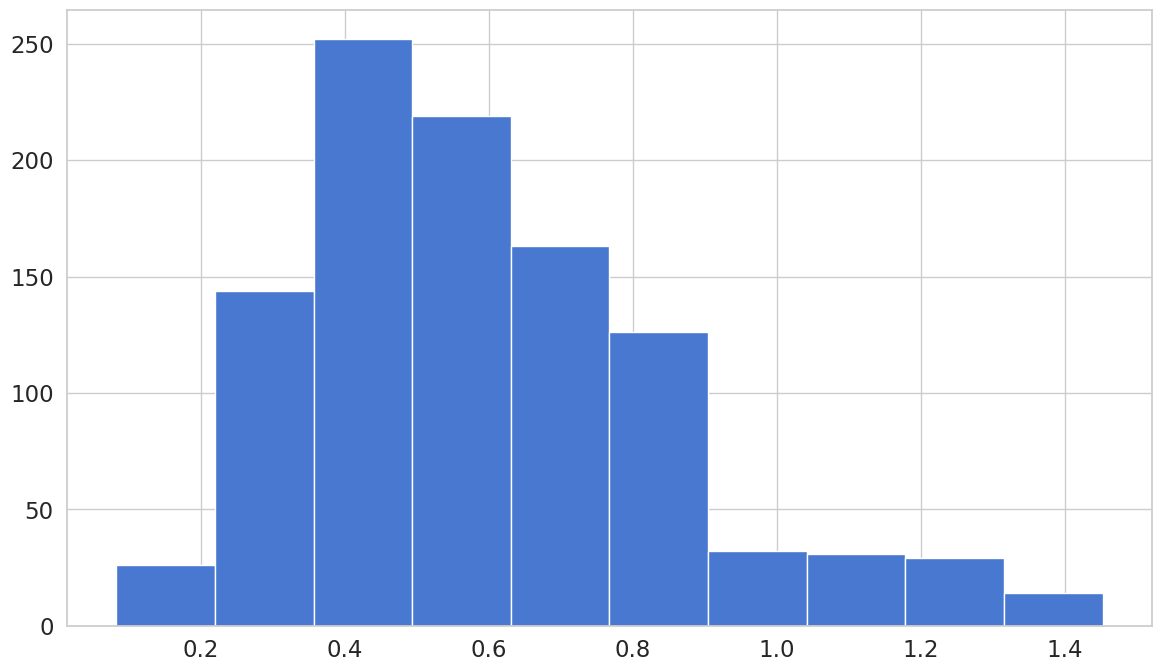

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[(reconstructionErrorDF['Churn']== 0) & (reconstructionErrorDF['pred_loss'] < 10)]
_ = ax.hist(normal_error_df.pred_loss.values, bins=10)

# Ошибки восстановления для оставшихся клиентов

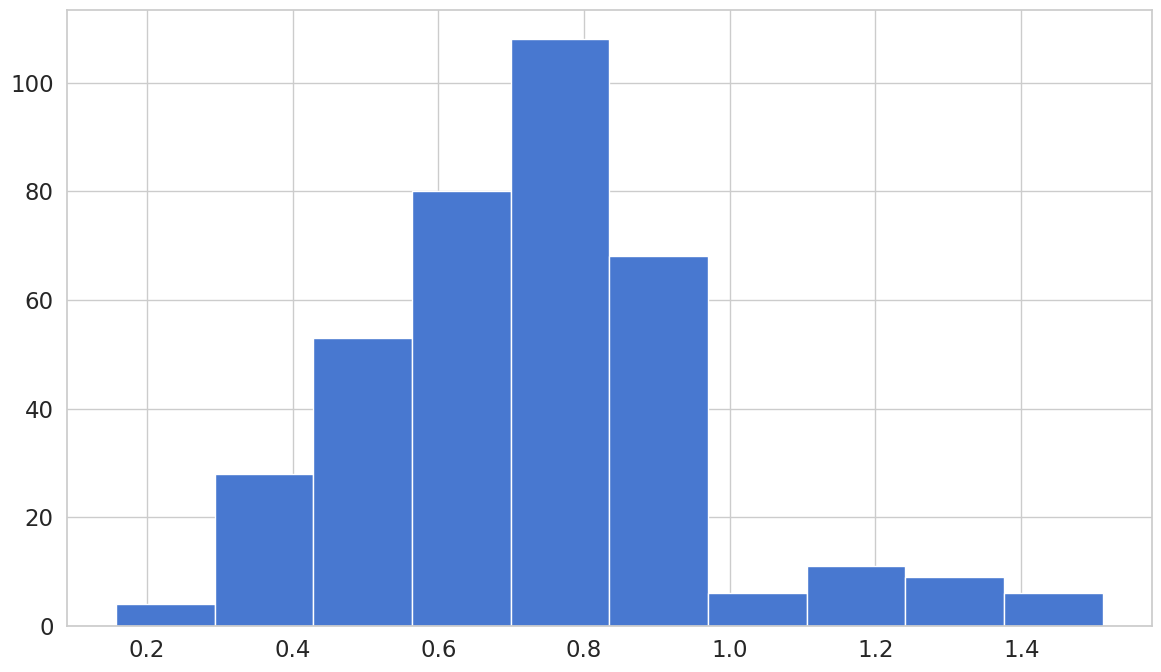

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)
fraud_error_df = reconstructionErrorDF[(reconstructionErrorDF['Churn']== 1) ]
_ = ax.hist(fraud_error_df.pred_loss.values, bins=10)

Автоэнкодер в текущей конфигурации не подходит для обнаружения оттока в моем датасете. Ошибки одинаковые для обоих классов, модель не разделяет аномалии...

## ROC Curves

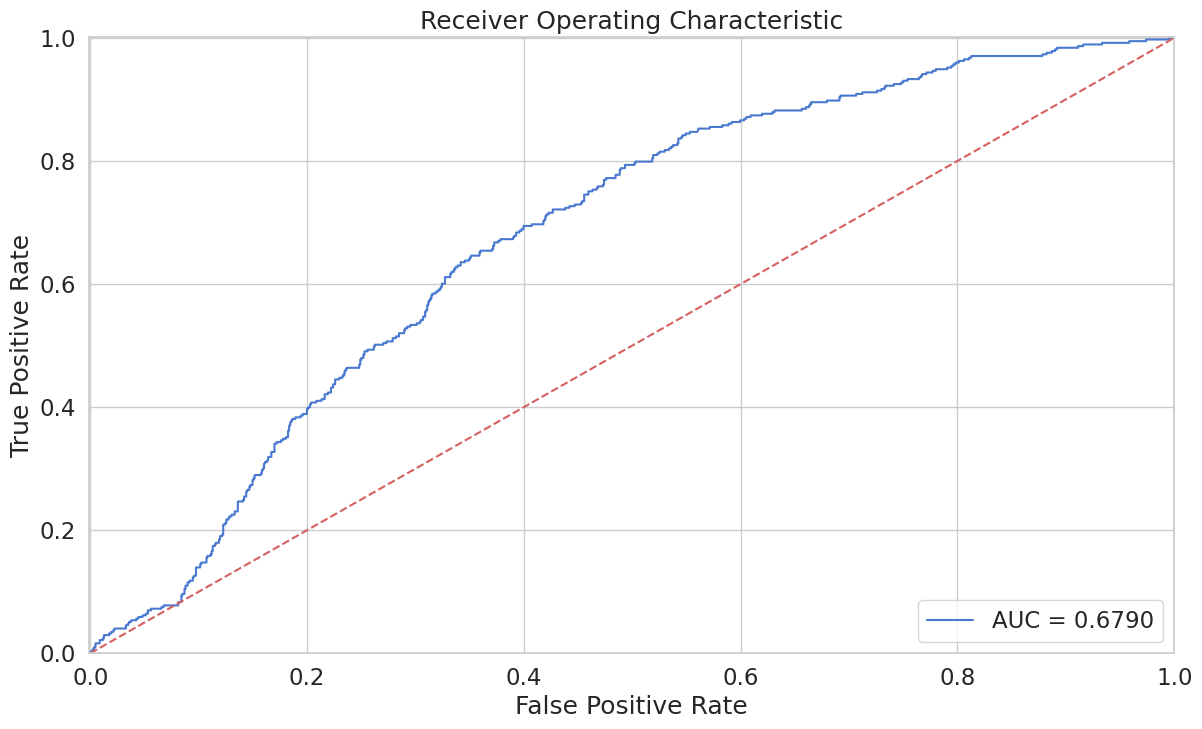

In [37]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF.Churn, reconstructionErrorDF.pred_loss)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

Модель не работает для обнаружения оттока. Автоэнкодер в данном случае не подходит для моей задачи.

## Precision vs Recall

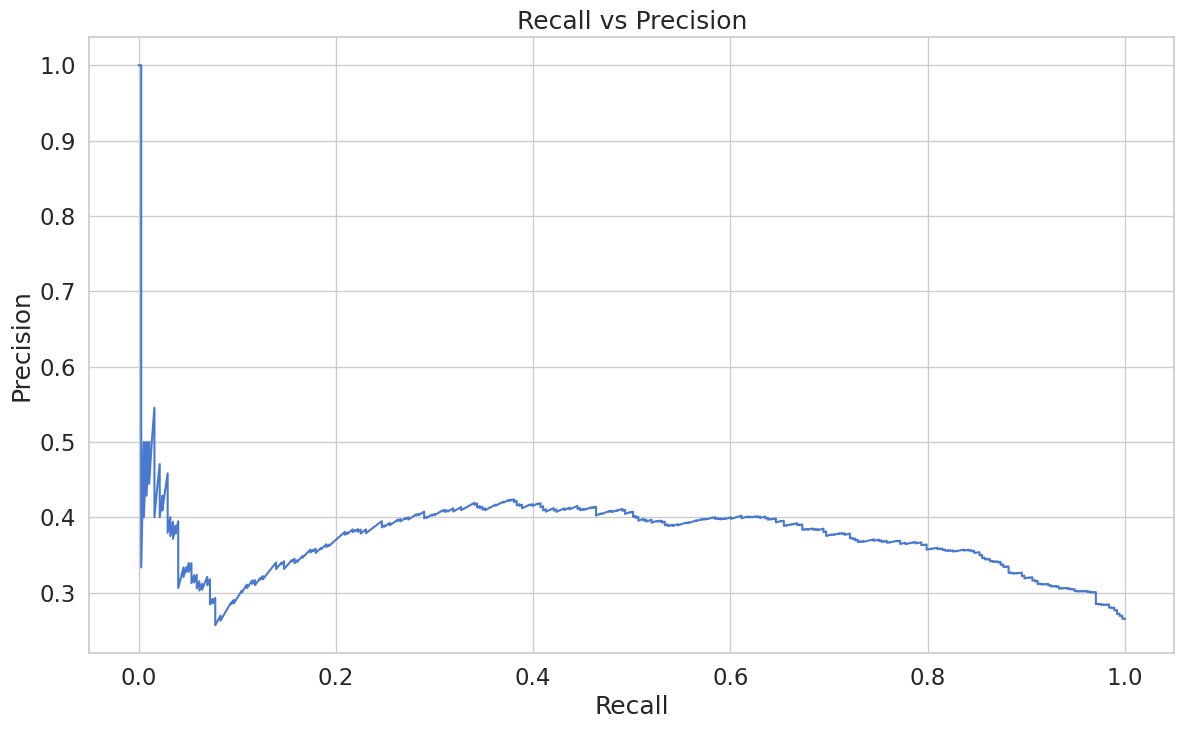

In [39]:
precision, recall, th = precision_recall_curve(reconstructionErrorDF.Churn, reconstructionErrorDF.pred_loss)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

По моему, PR-кривая подтверждает, что автоэнкодер плохо разделяет классы (опять)

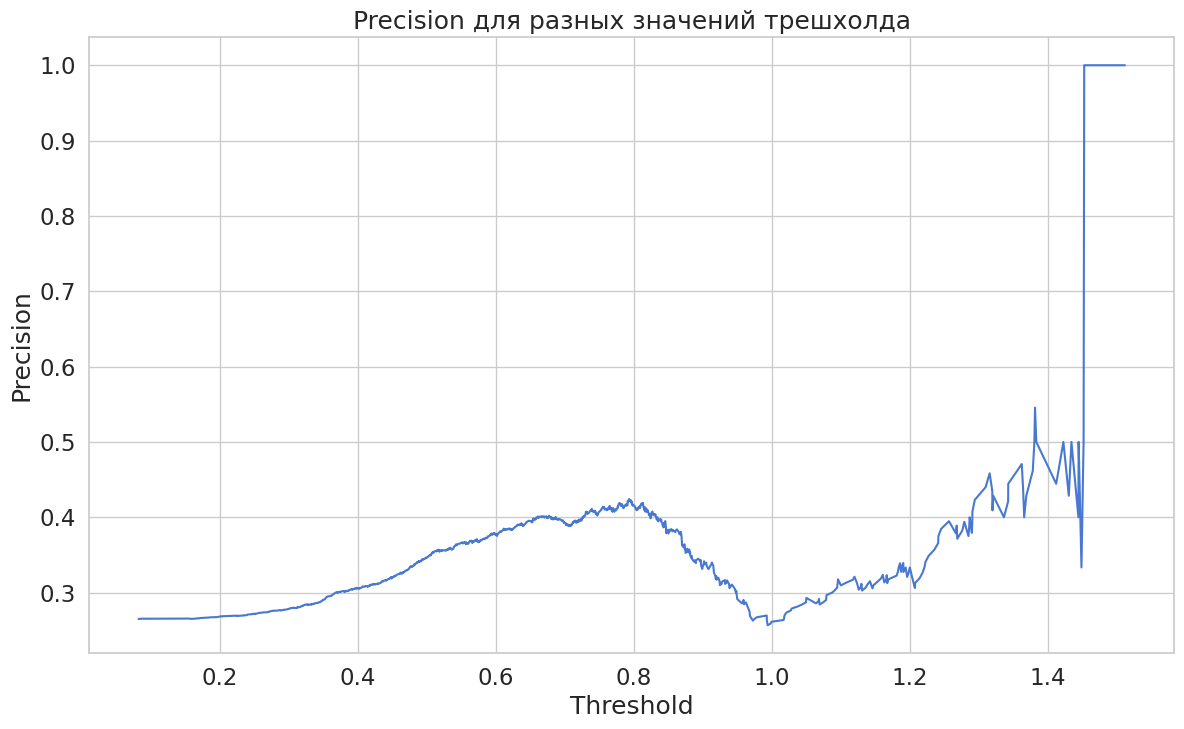

In [40]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

И здесь тоже видим автоэнкодер не разделяет классы

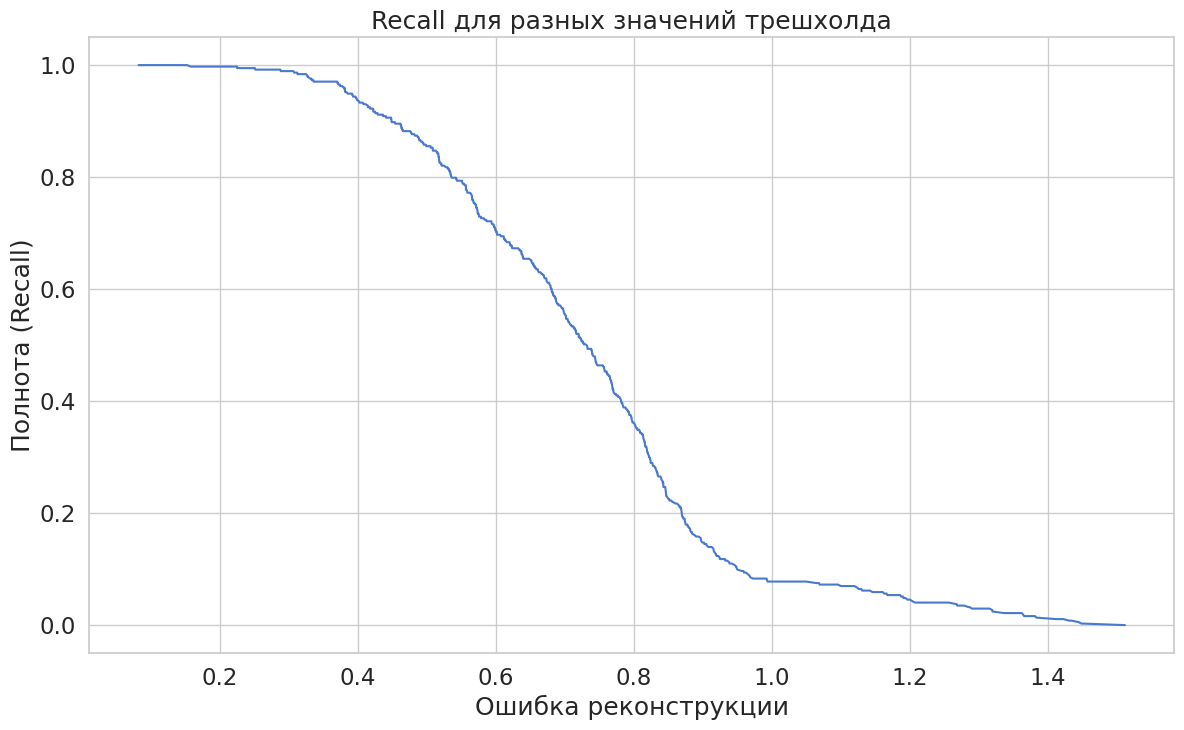

In [41]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

## Используем модель для того, чтобы сделать предсказание

In [61]:
threshold = 0.8

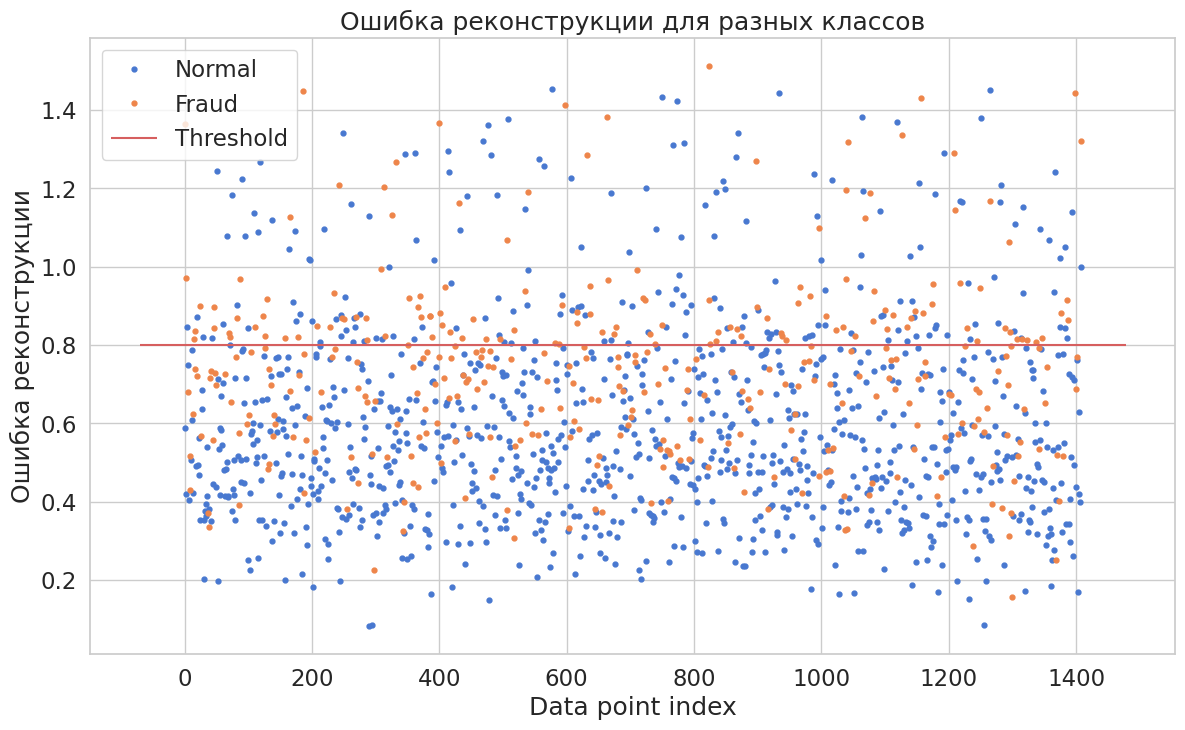

In [62]:
groups = reconstructionErrorDF.groupby('Churn')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

График наглядно показывает, что автоэнкодер не разделяет ушедших и оставшихся клиентов. Точки классов хаотично разбросаны, нет области, где был бы только один класс

/tmp/ipykernel_17162/3871755365.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Blues'));


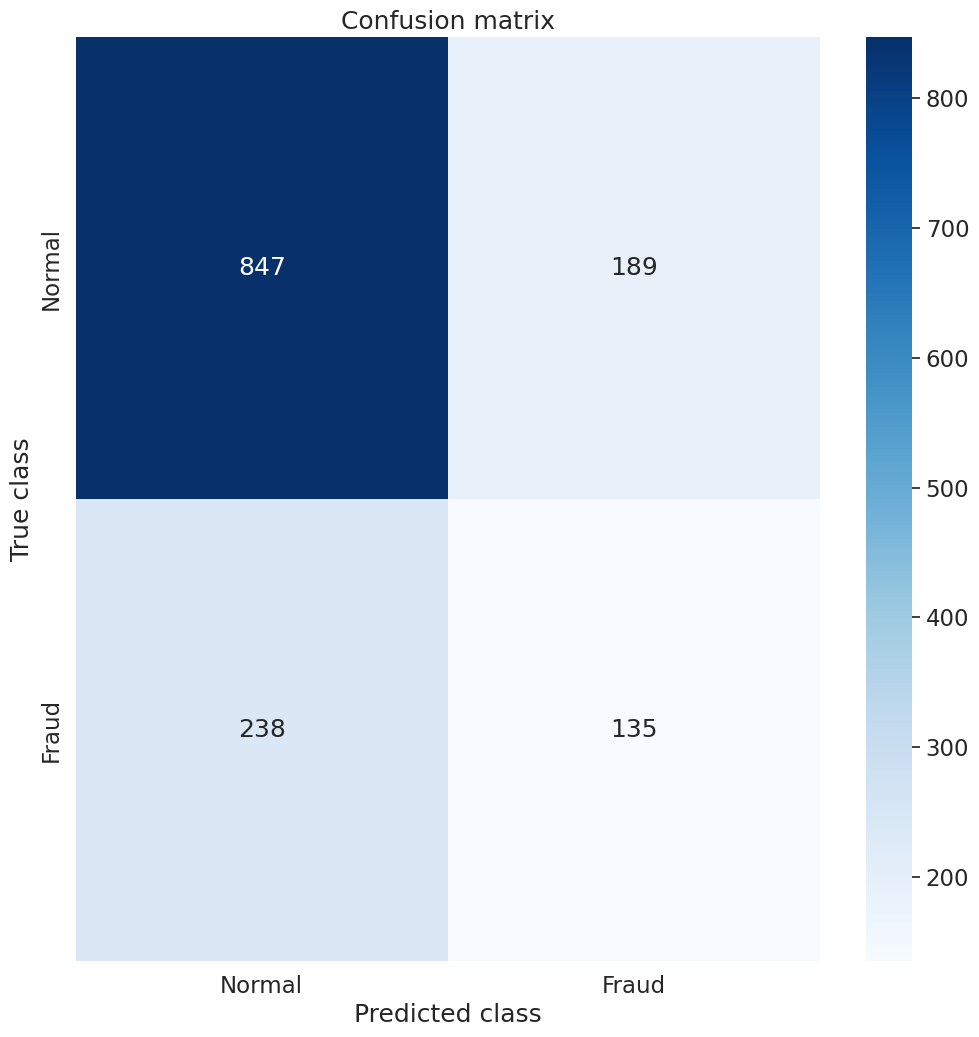

In [63]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.Churn, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Blues'));
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

871	- Оставшиеся - правильно предсказаны как оставшиеся<br>
189	- Оставшиеся - ошибочно предсказаны как ушедшие<br>
238	- Ушедшие - ошибочно предсказаны как оставшиеся<br>
135	- Ушедшие - правильно предсказаны как ушедшие<br>

В общем, автоэнкодер не подходит для обнаружения оттока клиентов. Лучше использовать другие методы классификации ( например, метод случайного леса).